In [46]:
import rasterio
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt

from joblib import Parallel, delayed #并行运算的库

from scipy import interpolate

In [47]:
# 修改工作路径
import os
# print(os.getcwd())
os.chdir('D:/0_PhdData/0_Paper/4_Global_P/4.2_Global_P_Calculation/') # 修改工作路径

全球数据

In [48]:
# Global土壤-气候数据读取

dt = pd.read_csv('./5_Model_data/Global_data/Global_data.csv')

# 使用每列的平均值填补 NA 值
dt = dt.apply(lambda x: x.fillna(x.mean()), axis=0)

In [49]:
x_OP_num =  np.arange(0, 100, 1)
x_OP_num

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [50]:
# 读取数据
dt_phy = pd.read_csv('./5_Model_data/Global_data/crop_phy.csv')

global_phy = pd.DataFrame({
    'rice_phy': dt_phy['phy_RICE'],
    'wheat_phy': dt_phy['phy_WHEA'],
    'maize_phy': dt_phy['phy_MAIZ'],
    'cereals_phy': dt_phy[['phy_BARL', 'phy_PMIL', 'phy_SMIL', 'phy_SORG', 'phy_OCER']].sum(axis=1),
    'cash_phy': dt_phy[['phy_SUGC', 'phy_SUGB', 'phy_COTT', 'phy_OFIB', 'phy_ACOF', 'phy_RCOF', 'phy_COCO', 'phy_TEAS', 'phy_TOBA', 'phy_REST']].sum(axis=1),
    'pulses_phy': dt_phy[['phy_BEAN', 'phy_CHIC', 'phy_COWP', 'phy_PIGE', 'phy_LENT', 'phy_OPUL', 'phy_SOYB', 'phy_GROU']].sum(axis=1),
    'roots_phy': dt_phy[['phy_POTA', 'phy_SWPO', 'phy_YAMS', 'phy_CASS', 'phy_ORTS']].sum(axis=1),
    'veg_phy': dt_phy[['phy_CNUT', 'phy_BANA', 'phy_PLNT', 'phy_TROF', 'phy_TEMF', 'phy_VEGE']].sum(axis=1),
    'oil_phy': dt_phy[['phy_OILP', 'phy_SUNF', 'phy_RAPE', 'phy_SESA', 'phy_OOIL']].sum(axis=1)
})

# 绘制全球数据集的PDP-偏依赖图

1. Maize

In [51]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Maize_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]
pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Maize.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

In [52]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['maize_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [53]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

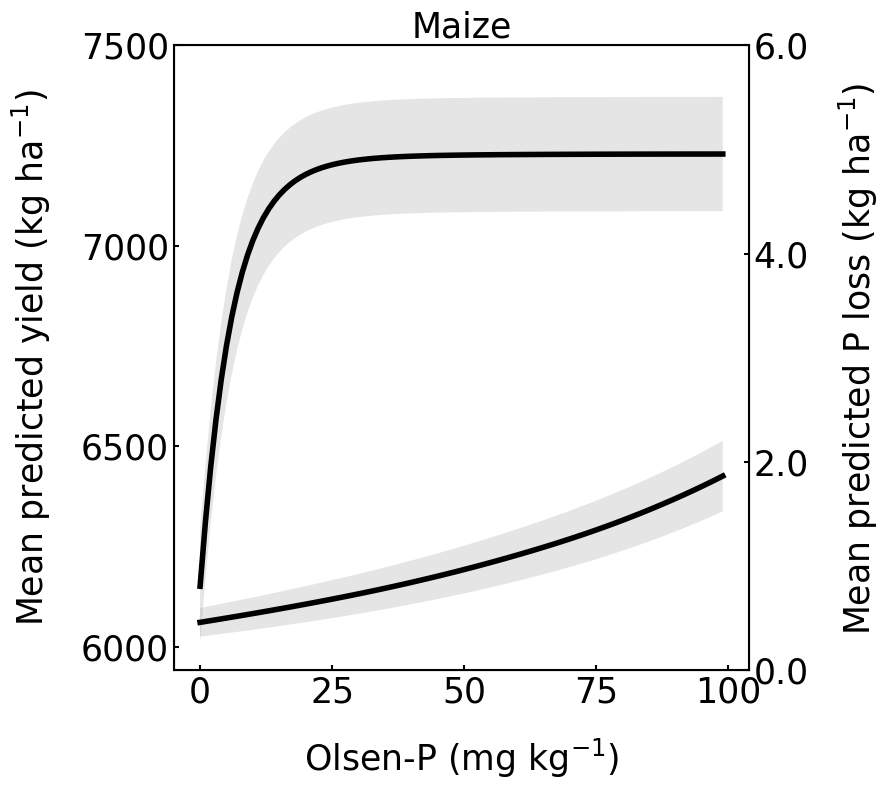

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV) 
Ploss_upper = Ploss_mean +adjusted_ploss_std
Ploss_lower = Ploss_mean -  adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(6000, 7501, 500), fontsize=25)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 6.01, 2), ['0.0', '2.0', '4.0', '6.0'], fontsize=25)
ax2.set_ylim(0,6)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Maize", fontsize=25)
plt.tight_layout()

2. Wheat

In [55]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Wheat_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]
pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Wheat.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

In [56]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['wheat_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [57]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

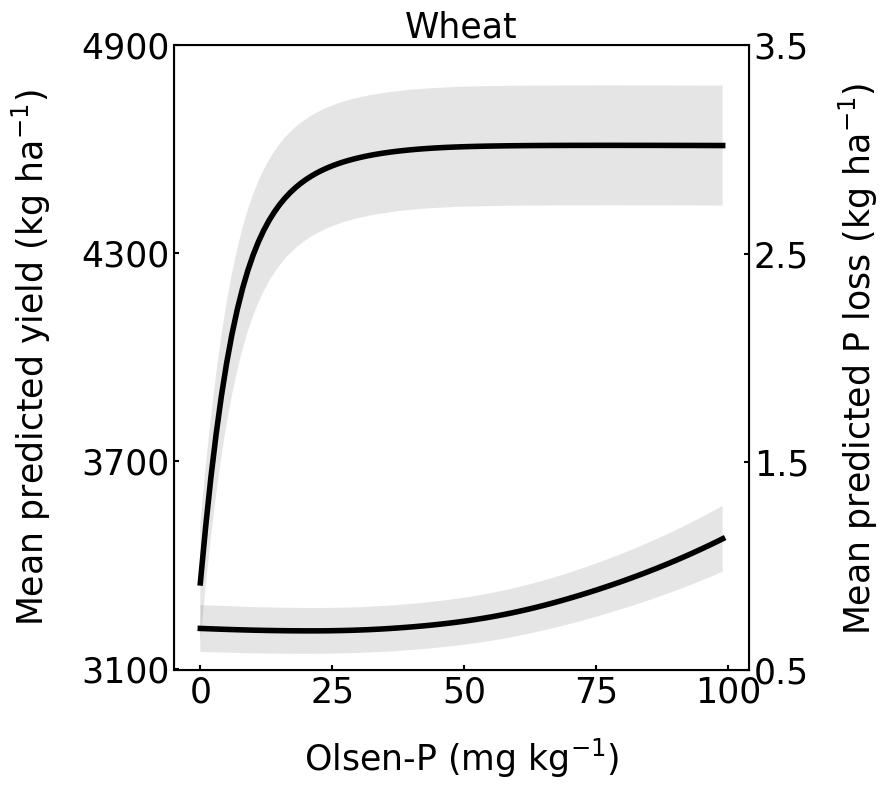

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean +  adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(3100, 4901, 600), fontsize=25)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0.5, 3.51, 1), fontsize=25)
ax2.set_ylim(0.5,3.5)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Wheat", fontsize=25)
plt.tight_layout()

3. Rice

In [59]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Rice_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]
pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Rice.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

In [60]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['rice_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [61]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

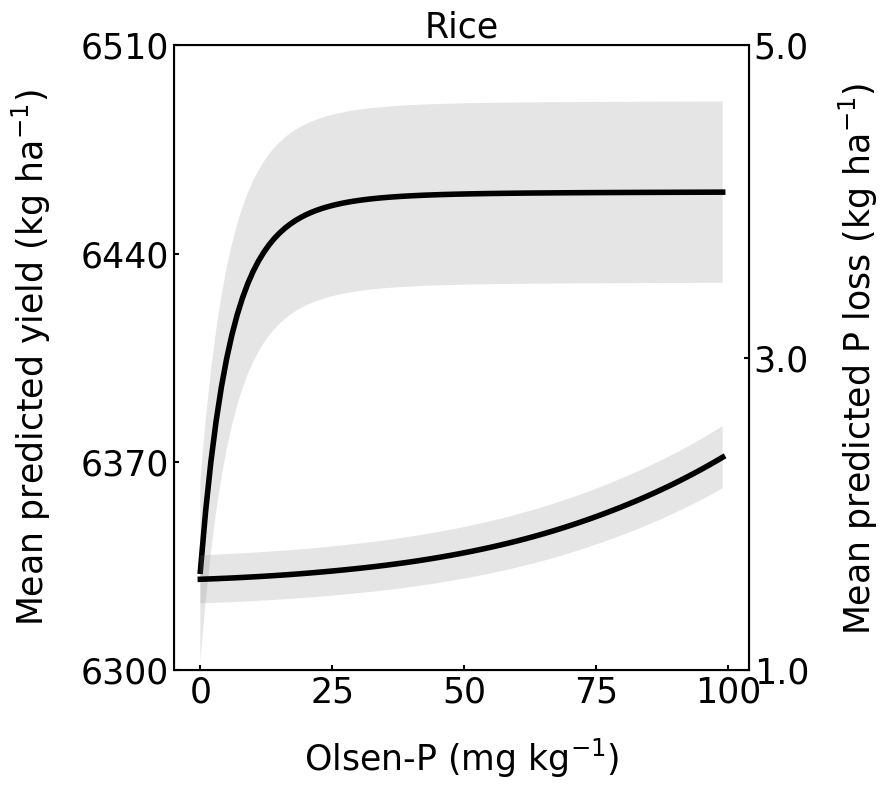

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(6300, 6511, 70), fontsize=25)
ax1.set_ylim(6300,6510)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(1, 5.1, 2), ['1.0', '3.0', '5.0'],fontsize=25)
ax2.set_ylim(1,5)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Rice", fontsize=25)
plt.tight_layout()

1. Other-cash

In [63]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [64]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(cash)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 2005.5, 6420.0)


pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

In [65]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['cash_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [66]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

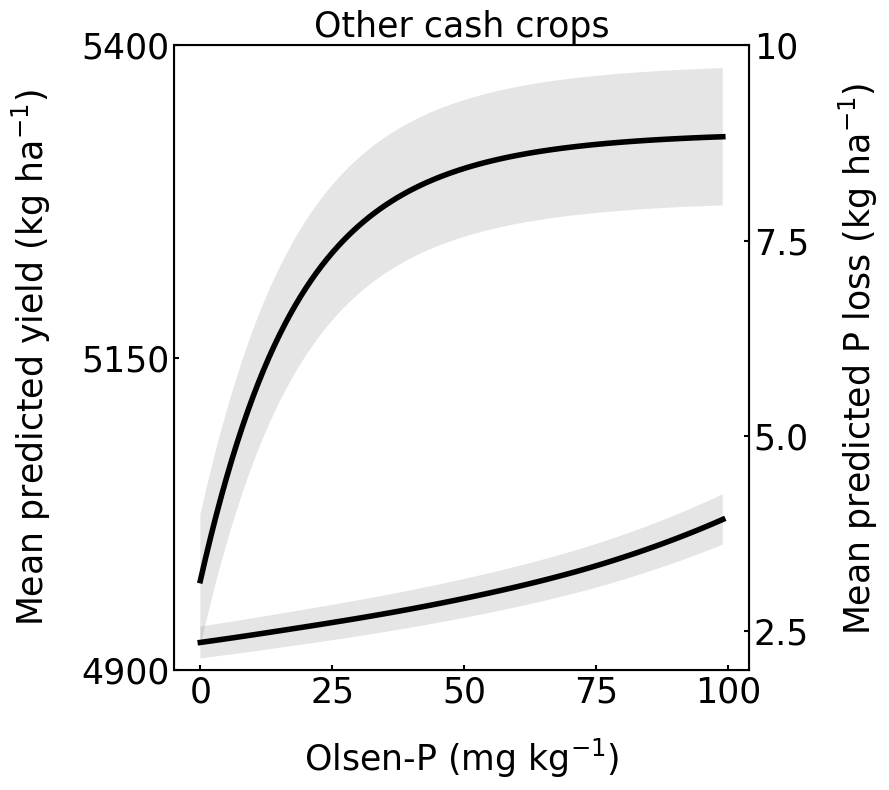

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean +  adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(4900, 5401, 250), fontsize=25)
ax1.set_ylim(4900, 5400)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Other cash crops", fontsize=25)
plt.tight_layout()

2. Other-cereals

In [68]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [73]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(cereals)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 2005.5, 8655.0)
print(pred_OPyield.mean())

pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

OP_0     5781.514822
OP_1     5797.213286
OP_2     5810.918722
OP_3     5822.876955
OP_4     5833.310329
            ...     
OP_95    5914.769135
OP_96    5914.785965
OP_97    5914.802724
OP_98    5914.819431
OP_99    5914.836086
Length: 100, dtype: float64


In [74]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['cereals_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [75]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

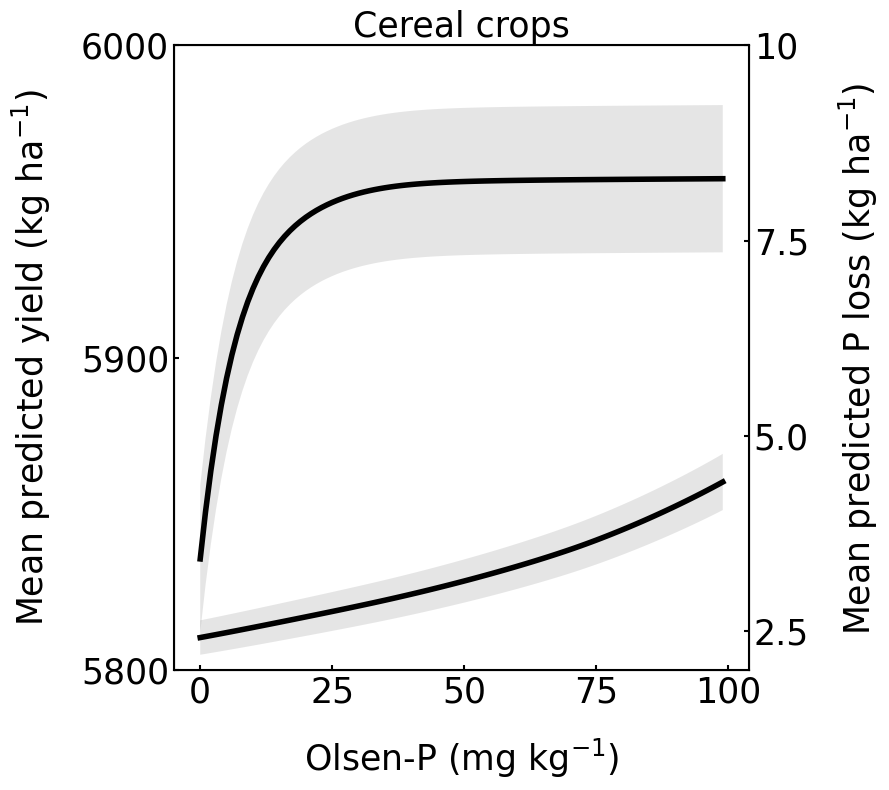

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(5800, 6001, 100), fontsize=25)
ax1.set_ylim(5800, 6000)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Cereal crops", fontsize=25)
plt.tight_layout()

3. Other-oil

In [87]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [88]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(oil)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 1000.5, 5613.0)
print(pred_OPyield.mean())

pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

OP_0     1937.919352
OP_1     1998.288223
OP_2     2056.298389
OP_3     2111.738300
OP_4     2164.436742
            ...     
OP_95    2746.974364
OP_96    2746.995959
OP_97    2747.016305
OP_98    2747.035478
OP_99    2747.053557
Length: 100, dtype: float64


In [89]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['oil_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [90]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

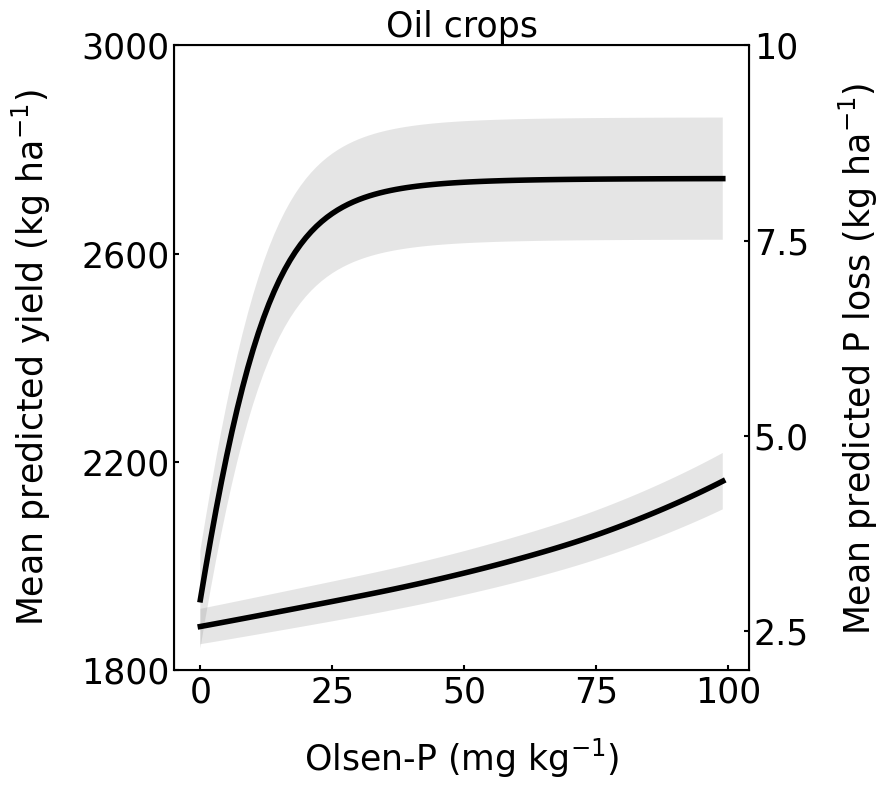

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(1800, 3001, 400), fontsize=25)
ax1.set_ylim(1800, 3000)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Oil crops", fontsize=25)
plt.tight_layout()

1. Other-pulses

In [103]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [104]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(pulses)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 1005, 3627.0)
print(pred_OPyield.mean())

pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

OP_0     2109.360443
OP_1     2116.142951
OP_2     2122.164525
OP_3     2127.513526
OP_4     2132.267536
            ...     
OP_95    2179.832219
OP_96    2179.929144
OP_97    2180.025874
OP_98    2180.122415
OP_99    2180.218770
Length: 100, dtype: float64


In [105]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['pulses_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [106]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

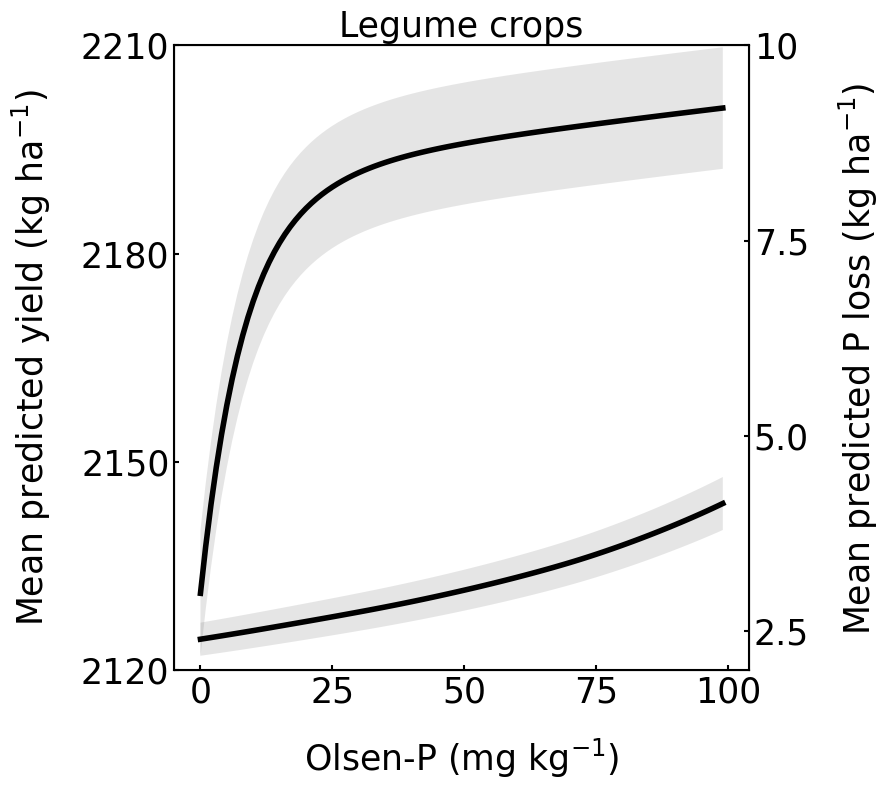

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(2120, 2211, 30), fontsize=25)
ax1.set_ylim(2120, 2210)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Legume crops", fontsize=25)
plt.tight_layout()

1. Other-root

In [126]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [127]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(roots)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 10000, 55500.0)
print(pred_OPyield.mean())

pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

OP_0     30985.790580
OP_1     30996.262514
OP_2     31005.875166
OP_3     31014.699351
OP_4     31022.800765
             ...     
OP_95    31123.831771
OP_96    31123.853394
OP_97    31123.873423
OP_98    31123.891941
OP_99    31123.909046
Length: 100, dtype: float64


In [128]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['roots_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [129]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

In [131]:
print(pred_OPyield_crop.mean())

OP_0     29482.614571
OP_1     29491.498937
OP_2     29499.658592
OP_3     29507.153895
OP_4     29514.040617
             ...     
OP_95    29601.183097
OP_96    29601.196886
OP_97    29601.209235
OP_98    29601.220192
OP_99    29601.229871
Length: 100, dtype: float64


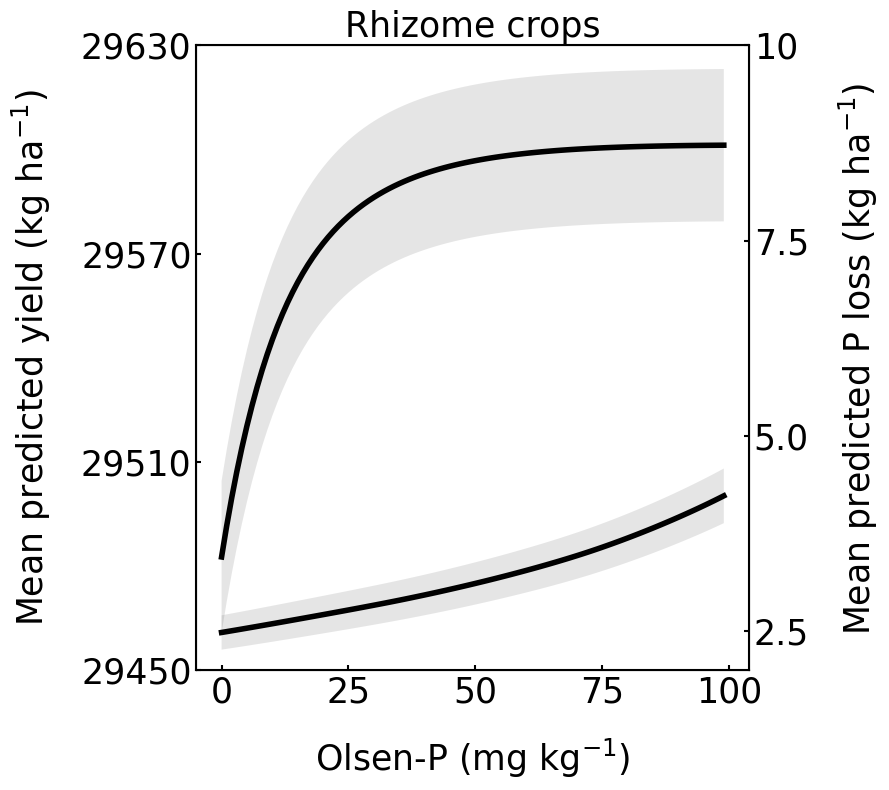

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(29450, 29631, 60), fontsize=25)
ax1.set_ylim(29450, 29630)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Rhizome crops", fontsize=25)
plt.tight_layout()

1. Other-veg

In [148]:
def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [149]:
# Global土壤-气候数据读取

pred_OPyield = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/0_Crop_yield/Other(veg)_pred_OPyield.csv')
pred_OPyield = pred_OPyield.iloc[:,0:100]/100

pred_OPyield = custom_denormalize(pred_OPyield, 12000.0, 120060.0)
print(pred_OPyield.mean())

pred_OPploss = pd.read_csv('./9_Major_revision/0_New_Data\Model_output_data/2_Crop_Ploss/Ploss_Other.csv')
pred_OPploss = pred_OPploss.iloc[:,0:100]

OP_0     69309.825032
OP_1     69351.097193
OP_2     69389.801906
OP_3     69426.107089
OP_4     69460.169656
             ...     
OP_95    70004.504394
OP_96    70004.334330
OP_97    70004.147462
OP_98    70003.944419
OP_99    70003.725839
Length: 100, dtype: float64


In [150]:
pred_OPyield_crop = pred_OPyield.copy()
# 计算分母
denominator = global_phy['veg_phy']

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPyield_crop.loc[denominator == 0.0, :] = np.nan
pred_OPyield_crop = pred_OPyield_crop.dropna()

In [151]:
pred_OPploss_crop = pred_OPploss.copy()

# 当 denominator 为 0 时，把整行设为 NaN
pred_OPploss_crop.loc[denominator == 0.0, :] = np.nan
pred_OPploss_crop = pred_OPploss_crop.dropna()

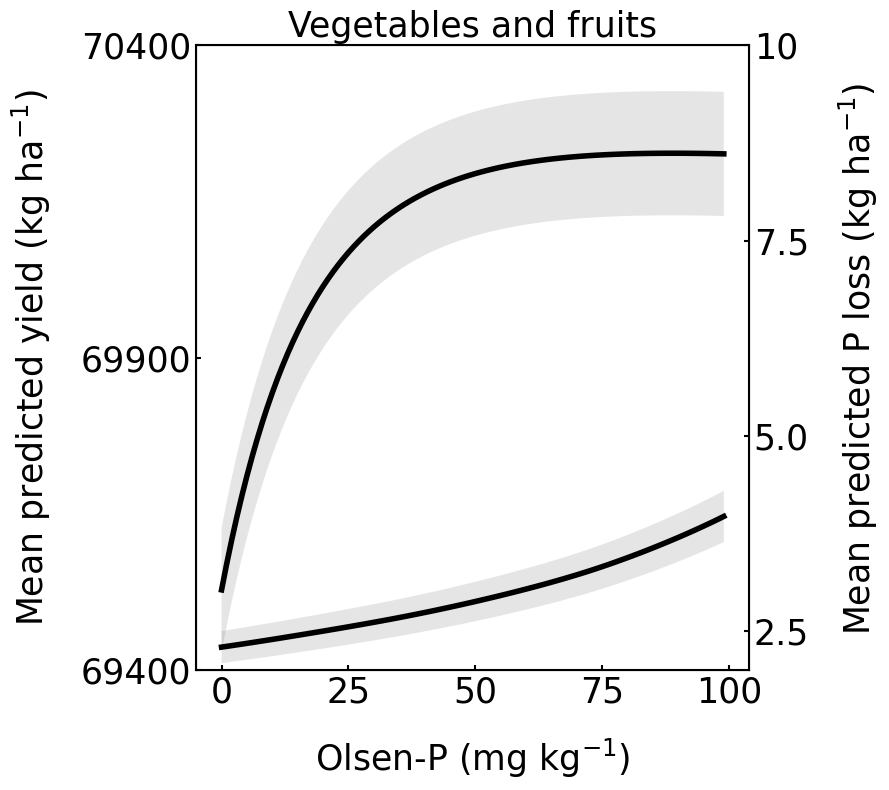

In [ ]:
# yield计算
Yield_mean = pred_OPyield_crop.mean(axis=0)
Yield_mean = np.array(Yield_mean)

Yield_std = pred_OPyield_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Yield_std / Yield_mean  # 计算变异系数
adjusted_yield_std = Yield_std / (1 + CV)  # 调整标准差
Yield_upper = Yield_mean + adjusted_yield_std
Yield_lower = Yield_mean - adjusted_yield_std

# loss计算
Ploss_mean = pred_OPploss_crop.mean(axis=0)
Ploss_mean = np.array(Ploss_mean)

Ploss_std = pred_OPploss_crop.std(axis=0)  # 按照OP水平计算标准差

CV = Ploss_std / Ploss_mean  # 计算变异系数
adjusted_ploss_std = Ploss_std / (1 + CV)  # 调整标准差
Ploss_upper = Ploss_mean + adjusted_ploss_std
Ploss_lower = Ploss_mean - adjusted_ploss_std

# 绘图
fig, ax1 = plt.subplots(figsize=(9, 8))
# 绘制平均值曲线
ax1.plot(x_OP_num, Yield_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax1.fill_between(x_OP_num, Yield_lower, Yield_upper, facecolor='grey', alpha=0.2, edgecolor='none')

# 设置 x 和 y 的刻度间隔
ax1.set_xticks(range(0, 101, 25), fontsize=25)
ax1.set_yticks(np.arange(69400, 70401, 500), fontsize=25)
ax1.set_ylim(69400, 70400)
ax1.set_xlabel("Olsen-P (mg kg$^{-1}$)", fontsize=25, labelpad=20)
ax1.set_ylabel("Mean predicted yield (kg ha$^{-1}$)", fontsize=25, labelpad=20)
ax1.tick_params(axis='x', labelsize=25, width=1.5)  # 设置 x 轴字体大小
ax1.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 y 轴字体大小
# 第二条曲线和第二 y 轴
ax2 = ax1.twinx()

# 绘制平均值曲线
ax2.plot(x_OP_num, Ploss_mean, label='Mean', color='black', linewidth=4)
# 添加置信区间
ax2.fill_between(x_OP_num, Ploss_lower, Ploss_upper, facecolor='grey', alpha=0.2, edgecolor='none')

ax2.set_ylabel("Mean predicted P loss (kg ha$^{-1}$) ", fontsize=25, labelpad=20)
ax2.set_yticks(np.arange(0, 10.01, 2.5), ['0.0', '2.5', '5.0', '7.5', '10'], fontsize=25)
ax2.set_ylim(2,10)
ax2.tick_params(axis='y', labelsize=25, width=1.5)  # 设置 x 轴字体大小
# 图形美化
# 调整第二 y 轴的外边框线条宽度
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
plt.tick_params(direction='in')
ax1.tick_params(direction='in')
ax2.tick_params(direction='in')
plt.title("Vegetables and fruits", fontsize=25)
plt.tight_layout()